In [67]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from utils import radar_factory

sns.set_theme()
pd.set_option('display.max_colwidth',3000)

In [10]:
def calcula_nivel_maturidade(row, chave='iGovTI'):
    if row[chave] < 0.15:
        return 'Inexpressivo'
    elif row[chave] < 0.4:
        return 'Iniciando'
    elif row[chave] < 0.7:
        return 'Intermediário'
    else:
        return 'Aprimorado'

In [58]:
df_resultado_passado = pd.read_excel('dados/resultado_igovti_2020.xlsx').set_index('orgao').rename(index={'PMERJ': 'SEPM'})
df_resultado_passado['nivel_maturidade'] = df_resultado_passado.apply(calcula_nivel_maturidade, axis=1)

df_resultado_setoriais    = pd.read_excel('dados/resultado_igovti.xlsx').set_index('attribute_1')
df_resultado_proderj      = pd.read_excel('dados/resultado_igovti_PRODERJ_2022.xlsx').set_index('attribute_1')
df_resultado_igovti       = pd.concat([df_resultado_proderj, df_resultado_setoriais])[['iGovTI', 'GovernancaTI', 'iGestTI', 'PlanejamentoTI', 'PessoasTI', 'ProcessosTI']]
df_resultado_igovti['nivel_maturidade'] = df_resultado_igovti.apply(calcula_nivel_maturidade, axis=1)

# iGovTI de 2020

In [59]:
df_resultado_passado

,iGovTI,GovernancaTI,iGestTI,PlanejamentoTI,PessoasTI,ProcessosTI,nivel_maturidade
orgao,,,,,,,
AGERIO,0.54,0.58,0.51,0.43,0.85,0.33,Intermediário
ALERJ,0.39,0.21,0.58,0.52,0.88,0.41,Iniciando
CEDAE,0.21,0.09,0.33,0.22,0.69,0.16,Iniciando
DETRAN,0.44,0.48,0.40,0.35,0.39,0.44,Intermediário
INEA,0.32,0.24,0.40,0.43,0.72,0.13,Iniciando
MPRJ,0.41,0.62,0.21,0.10,0.00,0.45,Intermediário
PCIVIL,0.53,0.43,0.62,0.65,0.88,0.42,Intermediário
SEPM,0.14,0.09,0.19,0.16,0.18,0.23,Inexpressivo
PRODERJ,0.39,0.40,0.38,0.10,0.84,0.29,Iniciando


# Comparação entre 2020 e 2022

In [63]:
df_comparativo = df_resultado_passado.join(df_resultado_igovti, lsuffix='_2020', rsuffix='_2022').dropna()

df_comparativo['Δ (iGovTI)'] = (df_comparativo['iGovTI_2022']/df_comparativo['iGovTI_2020']) - 1
df_comparativo['Δ (GovernancaTI)'] = (df_comparativo['GovernancaTI_2022']/df_comparativo['GovernancaTI_2020']) - 1
df_comparativo['Δ (iGestTI)'] = (df_comparativo['iGestTI_2022']/df_comparativo['iGestTI_2020']) - 1

df_comparativo['Δ (PlanejamentoTI)'] = (df_comparativo['PlanejamentoTI_2022']/df_comparativo['PlanejamentoTI_2020']) - 1
df_comparativo['Δ (PessoasTI)'] = (df_comparativo['PessoasTI_2022']/df_comparativo['PessoasTI_2020']) - 1
df_comparativo['Δ (ProcessosTI)'] = (df_comparativo['ProcessosTI_2022']/df_comparativo['ProcessosTI_2020']) - 1

df_comparativo = df_comparativo.replace([np.inf, -np.inf], np.nan)
df_comparativo

,iGovTI_2020,GovernancaTI_2020,iGestTI_2020,PlanejamentoTI_2020,PessoasTI_2020,ProcessosTI_2020,nivel_maturidade_2020,iGovTI_2022,GovernancaTI_2022,iGestTI_2022,PlanejamentoTI_2022,PessoasTI_2022,ProcessosTI_2022,nivel_maturidade_2022,Δ (iGovTI),Δ (GovernancaTI),Δ (iGestTI),Δ (PlanejamentoTI),Δ (PessoasTI),Δ (ProcessosTI)
orgao,,,,,,,,,,,,,,,,,,,,
AGERIO,0.54,0.58,0.51,0.43,0.85,0.33,Intermediário,0.716952,0.758782,0.675123,0.605357,0.788517,0.644992,Aprimorado,0.327690,0.308245,0.323770,0.407807,-0.072333,0.954523
DETRAN,0.44,0.48,0.40,0.35,0.39,0.44,Intermediário,0.290057,0.103108,0.477005,0.509524,0.518780,0.413668,Iniciando,-0.340781,-0.785191,0.192512,0.455782,0.330204,-0.059846
INEA,0.32,0.24,0.40,0.43,0.72,0.13,Iniciando,0.085430,0.087774,0.083086,0.050000,0.036840,0.150590,Inexpressivo,-0.733030,-0.634274,-0.792284,-0.883721,-0.948833,0.158382
SEPM,0.14,0.09,0.19,0.16,0.18,0.23,Inexpressivo,0.161353,0.146740,0.175966,0.388095,0.030002,0.104997,Iniciando,0.152521,0.630442,-0.073862,1.425595,-0.833320,-0.543492
PRODERJ,0.39,0.40,0.38,0.10,0.84,0.29,Iniciando,0.718105,0.527187,0.909023,1.000000,1.000000,0.764160,Aprimorado,0.841295,0.317968,1.392166,9.000000,0.190476,1.635035
SEDEC,0.02,0.03,0.00,0.00,0.00,0.01,Inexpressivo,0.261133,0.060723,0.461543,0.575000,0.481425,0.343489,Iniciando,12.056657,1.024097,NaN,NaN,NaN,33.348880
SEEDUC,0.11,0.09,0.13,0.15,0.00,0.20,Inexpressivo,0.171897,0.103049,0.240745,0.216667,0.348453,0.174273,Iniciando,0.562699,0.144986,0.851885,0.444444,NaN,-0.128636
SEFAZ,0.21,0.17,0.25,0.29,0.00,0.39,Iniciando,0.343368,0.165158,0.521578,1.000000,0.000000,0.518833,Iniciando,0.635084,-0.028484,1.086310,2.448276,NaN,0.330342
SEPLAG,0.17,0.21,0.13,0.15,0.00,0.22,Iniciando,0.087632,0.027930,0.147335,0.050000,0.276594,0.128966,Inexpressivo,-0.484517,-0.867002,0.133342,-0.666667,NaN,-0.413792


## Evolução iGovTI

In [54]:
df_igovti = df_comparativo[['iGovTI_2020', 'nivel_maturidade_2020', 'iGovTI_2022', 'nivel_maturidade_2022', 'Δ (iGovTI)']]
df_igovti['iGovTI_2020'] = df_igovti['iGovTI_2020'].apply('{:.4f}'.format)
df_igovti['iGovTI_2022'] = df_igovti['iGovTI_2022'].apply('{:.4f}'.format)
df_igovti['Δ (iGovTI)'] = (100*df_igovti['Δ (iGovTI)']).apply('{:.2f}%'.format)

df_igovti

C:\Users\augustocba\AppData\Local\Temp\ipykernel_14588\417985149.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_igovti['iGovTI_2020'] = df_igovti['iGovTI_2020'].apply('{:.4f}'.format)
C:\Users\augustocba\AppData\Local\Temp\ipykernel_14588\417985149.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_igovti['iGovTI_2022'] = df_igovti['iGovTI_2022'].apply('{:.4f}'.format)
C:\Users\augustocba\AppData\Local\Temp\ipykernel_14588\417985149.py:4: SettingWithCopyWarning: 
A value is trying to be set on a

,iGovTI_2020,nivel_maturidade_2020,iGovTI_2022,nivel_maturidade_2022,Δ (iGovTI)
orgao,,,,,
AGERIO,0.5400,Intermediário,0.7170,Aprimorado,32.77%
DETRAN,0.4400,Intermediário,0.2901,Iniciando,-34.08%
PRODERJ,0.3900,Iniciando,0.7181,Aprimorado,84.13%
INEA,0.3200,Iniciando,0.0854,Inexpressivo,-73.30%
SEFAZ,0.2100,Iniciando,0.3434,Iniciando,63.51%
SEPLAG,0.1700,Iniciando,0.0876,Inexpressivo,-48.45%
SEPM,0.1400,Inexpressivo,0.1614,Iniciando,15.25%
SEEDUC,0.1100,Inexpressivo,0.1719,Iniciando,56.27%
SEDEC,0.0200,Inexpressivo,0.2611,Iniciando,1205.67%


In [37]:
df_comparativo[['Δ (iGovTI)', 'Δ (GovernancaTI)', 'Δ (iGestTI)']].describe()

,Δ (iGovTI),Δ (GovernancaTI),Δ (iGestTI)
count,9.000000,9.000000,8.000000
mean,1.446402,0.012310,0.389230
std,4.015297,0.655109,0.699463
min,-0.733030,-0.867002,-0.792284
25%,-0.340781,-0.634274,0.081541
50%,0.327690,0.144986,0.258141
75%,0.635084,0.317968,0.910492
max,12.056657,1.024097,1.392166


## Distribuição da evolução do iGovTI pelos jurisdicionados

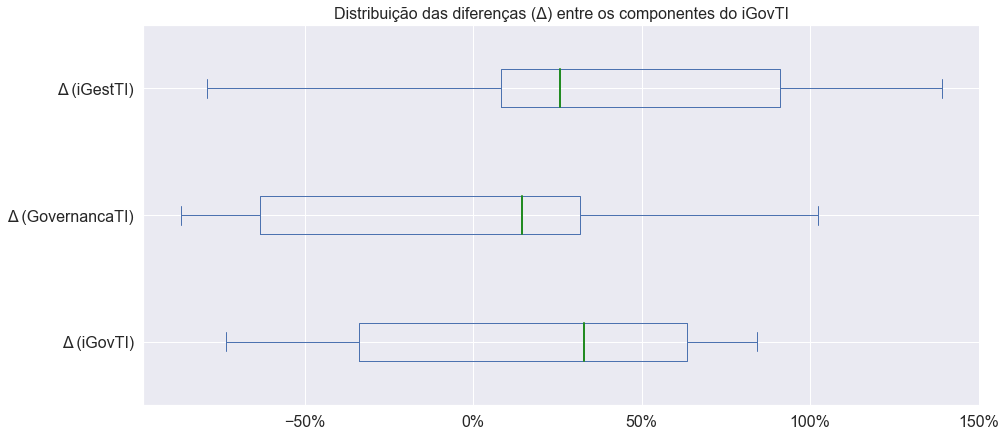

In [76]:
ax = (100*df_comparativo[['Δ (iGovTI)', 'Δ (GovernancaTI)', 'Δ (iGestTI)']]).plot.box(vert=False, figsize=(15, 7), fontsize=16, showfliers=False, medianprops = dict(color = "forestgreen", linewidth = 2))
ax.set_title('Distribuição das diferenças (Δ) entre os componentes do iGovTI', fontsize=16)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

## Distribuição da evolução do iGestTI pelos jurisdicionados

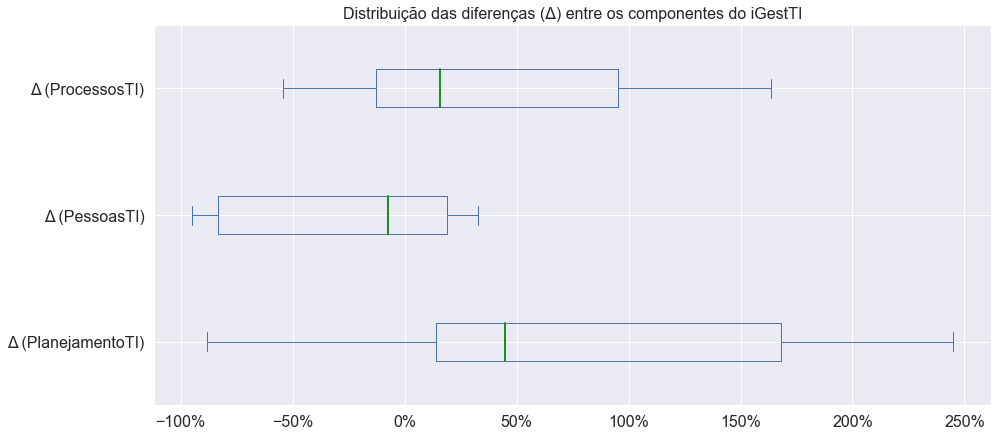

In [79]:
ax = (100*df_comparativo[['Δ (PlanejamentoTI)', 'Δ (PessoasTI)', 'Δ (ProcessosTI)']]).plot.box(vert=False, figsize=(15, 7), fontsize=16, showfliers=False, medianprops = dict(color = "forestgreen", linewidth = 2))
ax.set_title('Distribuição das diferenças (Δ) entre os componentes do iGestTI', fontsize=16)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

## Evolução dos níveis de maturidade dos jurisdicionados

In [38]:
df_comparativo[['nivel_maturidade_2020', 'nivel_maturidade_2022']]

,nivel_maturidade_2020,nivel_maturidade_2022
orgao,,
AGERIO,Intermediário,Aprimorado
DETRAN,Intermediário,Iniciando
PRODERJ,Iniciando,Aprimorado
INEA,Iniciando,Inexpressivo
SEFAZ,Iniciando,Iniciando
SEPLAG,Iniciando,Inexpressivo
SEPM,Inexpressivo,Iniciando
SEEDUC,Inexpressivo,Iniciando
SEDEC,Inexpressivo,Iniciando
